In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [53]:
# =====================================================
# Load Dataset & Basic Preprocessing
# =====================================================

df = pd.read_csv('../Data/electricity_demand.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)   

In [54]:
print("Total demand_MW:",df["demand_MW"].sum())
print("Avg demand_MW:",df["demand_MW"].mean())
print("std demand_MW:",df["demand_MW"].std())
print("Max demand_MW:",df["demand_MW"].max())
print("Min demand_MW:",df["demand_MW"].min())

Total demand_MW: 108858196.89999999
Avg demand_MW: 4142.244935312024
std demand_MW: 1087.7567985498533
Max demand_MW: 6527.4
Min demand_MW: 1344.5


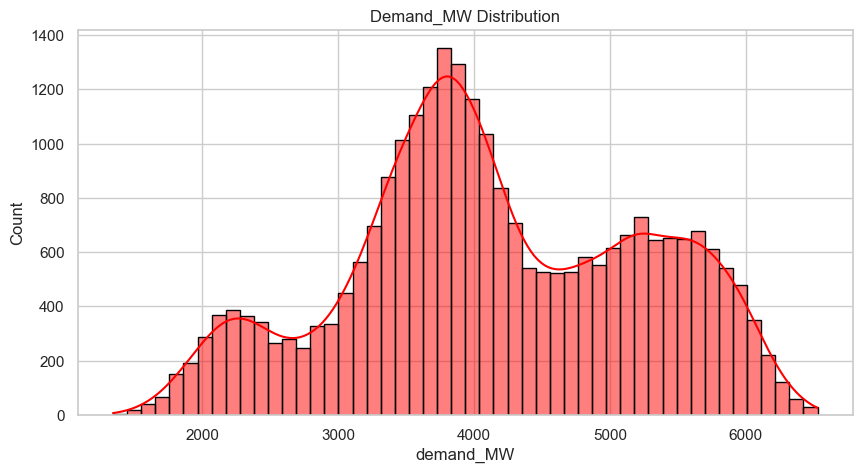

In [55]:
# Demand_MW Distribution:
plt.figure(figsize=(10,5))
sns.histplot(df["demand_MW"], bins=50, kde=True, color='red', edgecolor='black')
plt.title("Demand_MW Distribution")
plt.show()

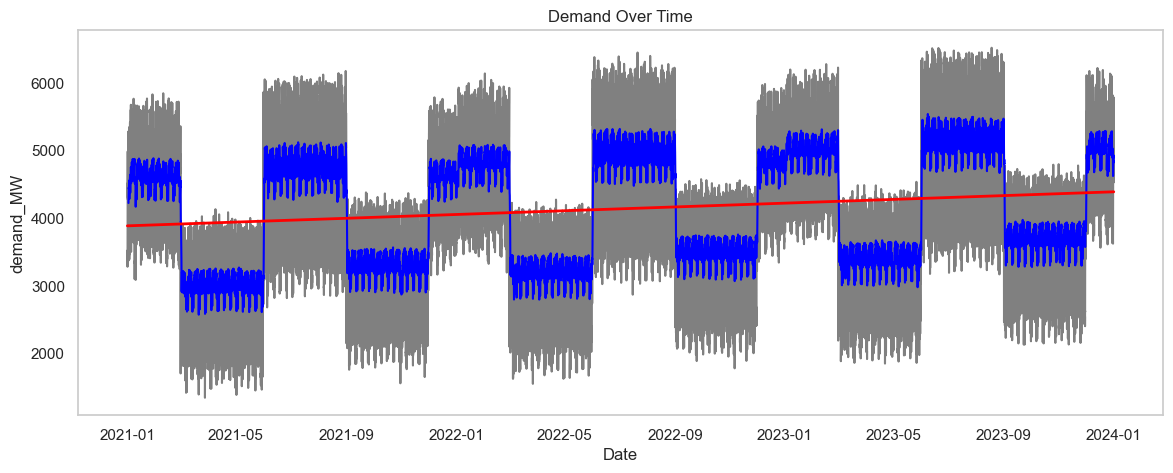

Slope: 0.0192


In [56]:
# Demand Over Time (line plot - full 3 years):
x = np.arange(len(df))
y = df['demand_MW'].values
coeffs = np.polyfit(x, y, deg=1)
trend_line = np.polyval(coeffs, x)

df['SMA_7'] = df['demand_MW'].rolling(window=30).mean()

plt.figure(figsize=(14,5))
plt.plot(df.index, df['demand_MW'], color='grey')
plt.plot(df['SMA_7'], label='SMA 7-day', color='blue')
plt.plot(df.index, trend_line, label='Trend Line (deg=1)', 
         color='red', linewidth=2)

plt.title("Demand Over Time")
plt.xlabel("Date")
plt.ylabel("demand_MW")
plt.grid()
plt.show()

print(f"Slope: {coeffs[0]:.4f}")

D:\Temp\ipykernel_13872\374101329.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='hour', y='demand_MW', errorbar=None, palette='viridis', legend=False)


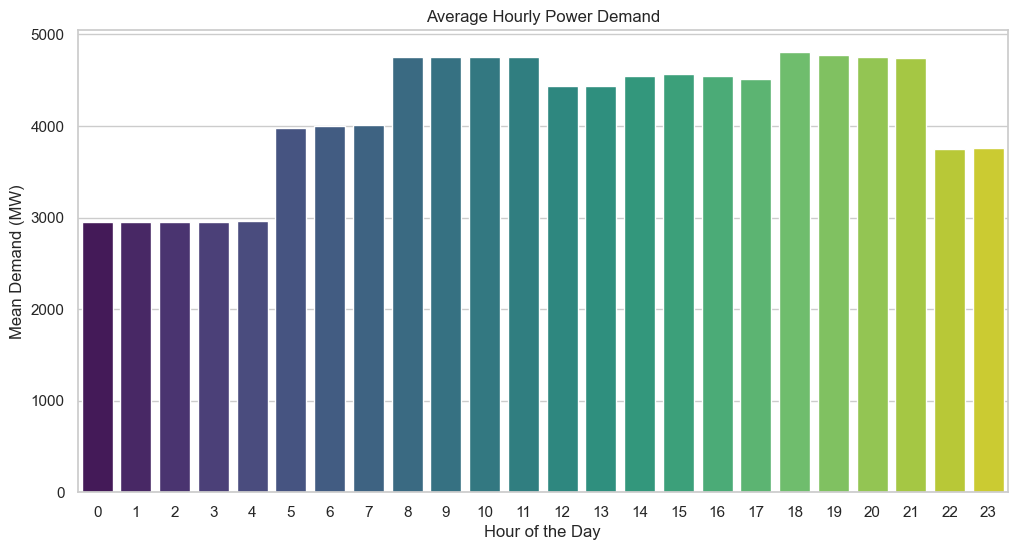

In [57]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.barplot(data=df, x='hour', y='demand_MW', errorbar=None, palette='viridis', legend=False)
plt.title('Average Hourly Power Demand')
plt.xlabel('Hour of the Day')
plt.ylabel('Mean Demand (MW)')
plt.show()

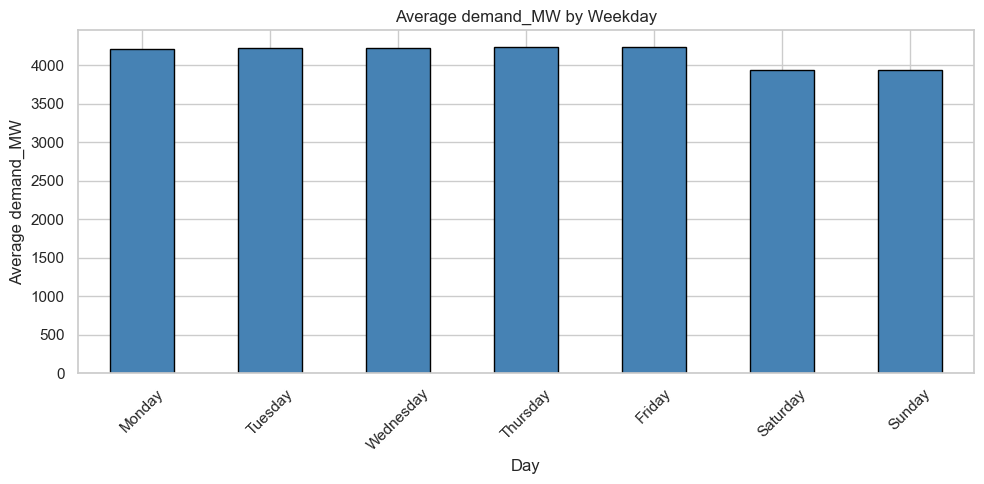

weekday
Monday       4209.364316
Tuesday      4216.501442
Wednesday    4217.236271
Thursday     4238.373424
Friday       4234.456476
Saturday     3941.958572
Sunday       3939.814464
Name: demand_MW, dtype: float64


In [58]:
df['weekday'] = df.index.day_name()

weekday_order = ['Monday','Tuesday','Wednesday',
                 'Thursday','Friday','Saturday','Sunday']

weekday_avg = df.groupby('weekday')['demand_MW'].mean()
weekday_avg = weekday_avg.reindex(weekday_order)

# Plot
plt.figure(figsize=(10,5))
weekday_avg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average demand_MW by Weekday')
plt.xlabel('Day')
plt.ylabel('Average demand_MW')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(weekday_avg)
df.drop("weekday", axis=1, inplace=True)

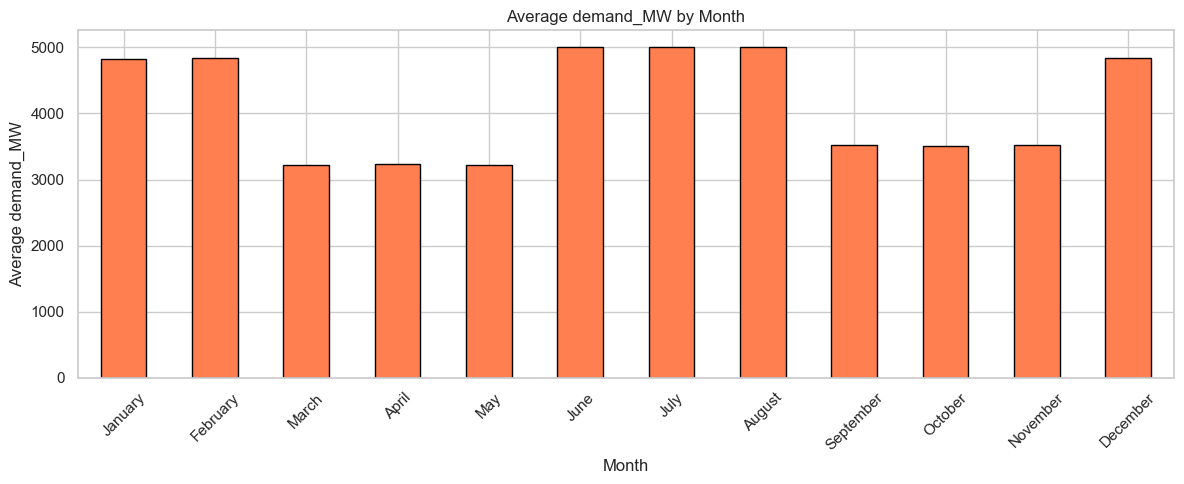

month
January      4819.927061
February     4835.719196
March        3222.682975
April        3229.674769
May          3224.516667
June         5007.337685
July         4999.046461
August       5000.820565
September    3528.210926
October      3512.860125
November     3516.008426
December     4835.704525
Name: demand_MW, dtype: float64


In [59]:
df['month'] = df.index.month_name()

month_order = ['January','February','March','April',
               'May','June','July','August',
               'September','October','November','December']

month_avg = df.groupby('month')['demand_MW'].mean()
month_avg = month_avg.reindex(month_order)

plt.figure(figsize=(12,5))
month_avg.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average demand_MW by Month')
plt.xlabel('Month')
plt.ylabel('Average demand_MW')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(month_avg)
df.drop("month", axis=1, inplace=True)

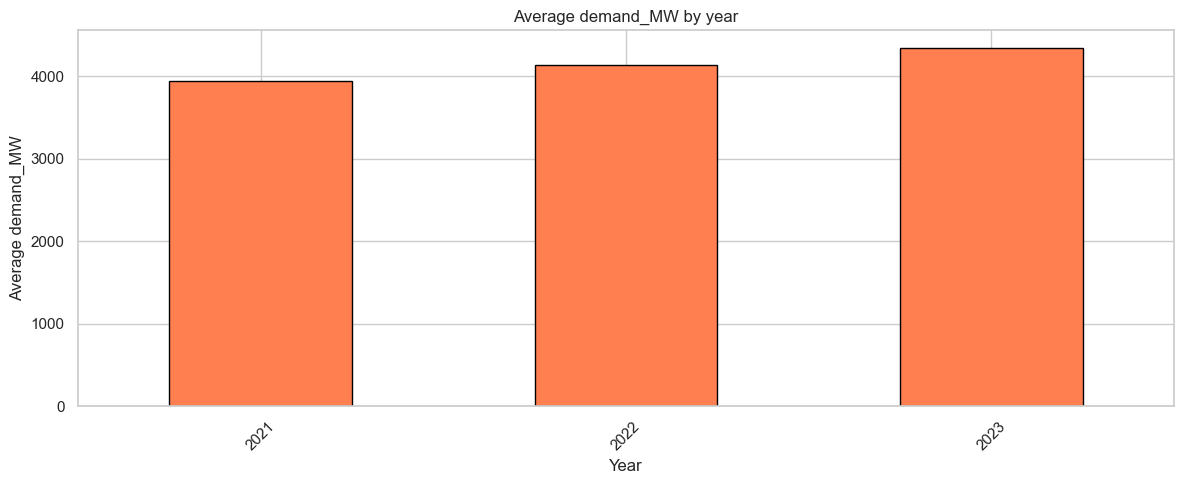

year
2021    3942.838151
2022    4143.412557
2023    4340.484098
Name: demand_MW, dtype: float64


In [60]:
df['year'] = df.index.year

year_revenue = df.groupby('year')['demand_MW'].mean()

plt.figure(figsize=(12,5))
year_revenue.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average demand_MW by year')
plt.xlabel('Year')
plt.ylabel('Average demand_MW')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(year_revenue)
df.drop("year", axis=1, inplace=True)

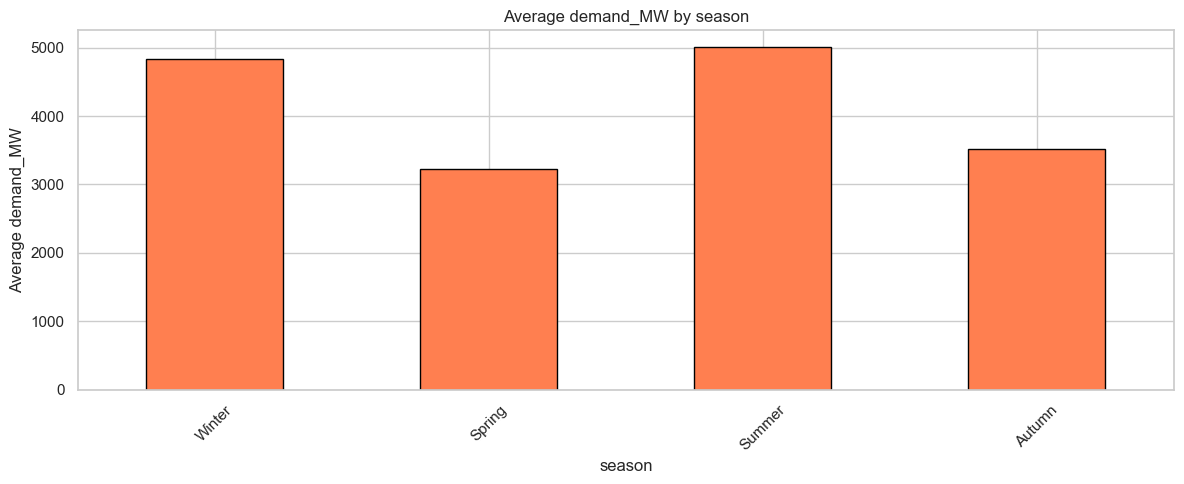

season
Winter    4830.274630
Spring    3225.580782
Summer    5002.347917
Autumn    3518.958730
Name: demand_MW, dtype: float64


In [61]:
order = ['Winter','Spring','Summer','Autumn']

season_revenue = df.groupby('season')['demand_MW'].mean()
season_revenue = season_revenue.reindex(order)

plt.figure(figsize=(12,5))
season_revenue.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average demand_MW by season')
plt.xlabel('season')
plt.ylabel('Average demand_MW')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(season_revenue)
df.drop("season", axis=1, inplace=True)

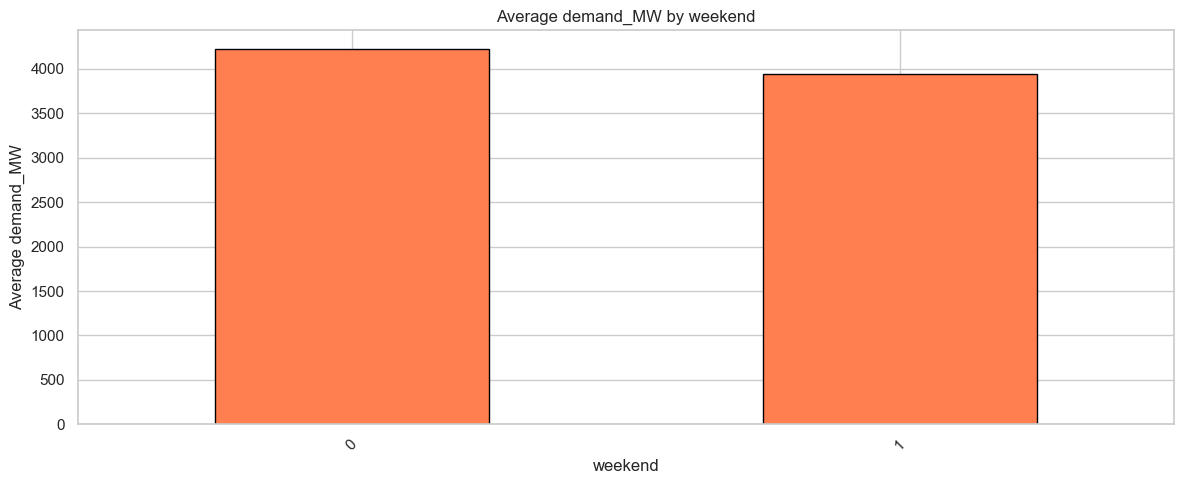

weekend
0    4223.200816
1    3940.886518
Name: demand_MW, dtype: float64


In [63]:
weekend_revenue = df.groupby('weekend')['demand_MW'].mean()

plt.figure(figsize=(12,5))
weekend_revenue.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average demand_MW by weekend')
plt.xlabel('weekend')
plt.ylabel('Average demand_MW')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(weekend_revenue)
df.drop("weekend", axis=1, inplace=True)

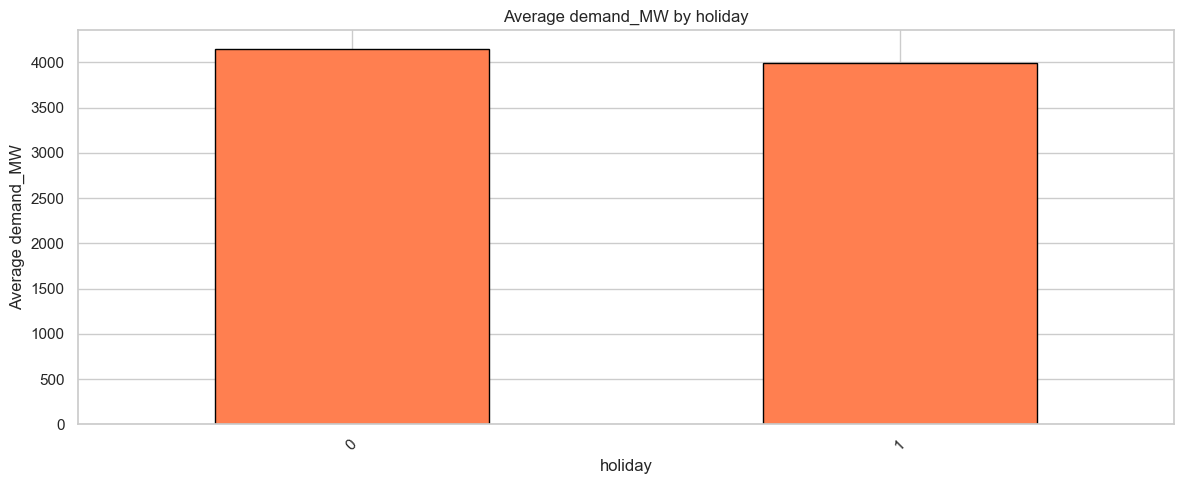

holiday
0    4146.052364
1    3991.639969
Name: demand_MW, dtype: float64


In [64]:
holiday_revenue = df.groupby('holiday')['demand_MW'].mean()

plt.figure(figsize=(12,5))
holiday_revenue.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average demand_MW by holiday')
plt.xlabel('holiday')
plt.ylabel('Average demand_MW')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(holiday_revenue)
df.drop("holiday", axis=1, inplace=True)